## Part 1 — Simple Linear Regression

In [104]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing(as_frame=True)
df = data.frame.copy()

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [105]:
X = df[["MedInc","HouseAge","Population"]]
y = df["MedHouseVal"]

X.shape, y.shape

((20640, 3), (20640,))

In [106]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2)

X_train.shape, X_test.shape

((16512, 3), (4128, 3))

In [107]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained.")

Model trained.


In [108]:
pred_test = model.predict(X_test)

pred_test[:5]

array([1.82006247, 3.75728657, 1.67014835, 2.23229535, 2.40663323])

In [109]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, pred_test)
r2  = r2_score(y_test, pred_test)

print("Test MSE:", mse)
print("Test R2 :", r2)

Test MSE: 0.6453431262068711
Test R2 : 0.5109897822820672


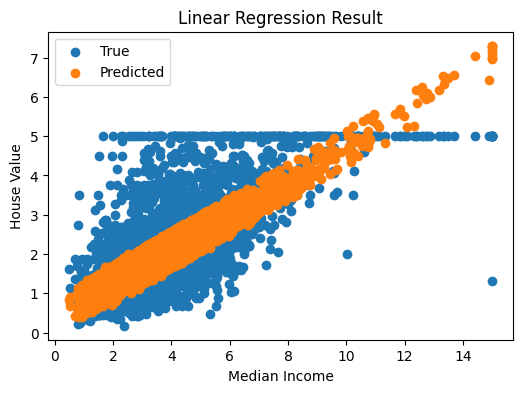

In [110]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(X_test.iloc[:, 0], y_test, label="True")
plt.scatter(X_test.iloc[:, 0], pred_test, label="Predicted")
plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.legend()
plt.title("Linear Regression Result")
plt.show()

## Part 2 — Simple Logistic Classification

In [111]:
# Create binary target from the SAME housing dataset

import pandas as pd
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing(as_frame=True)
df = data.frame.copy()

# create binary label
threshold = df["MedHouseVal"].median()
df["Expensive"] = (df["MedHouseVal"] > threshold).astype(int)

df[["MedHouseVal", "Expensive"]].head()

,MedHouseVal,Expensive
0,4.526,1
1,3.585,1
2,3.521,1
3,3.413,1
4,3.422,1


In [112]:
# features (use same ones as regression)

X = df[["MedInc", "HouseAge", "AveRooms"]]
y = df["Expensive"]

X.head()


,MedInc,HouseAge,AveRooms
0,8.3252,41.0,6.984127
1,8.3014,21.0,6.238137
2,7.2574,52.0,8.288136
3,5.6431,52.0,5.817352
4,3.8462,52.0,6.281853


In [113]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [114]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=2000)
clf.fit(X_train, y_train)

print("Classifier trained.")


Classifier trained.


In [115]:
pred = clf.predict(X_test)

pred[:10]


array([0, 0, 1, 1, 1, 1, 1, 1, 1, 1])

In [116]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, pred)
print("Accuracy:", acc)


Accuracy: 0.7720445736434108


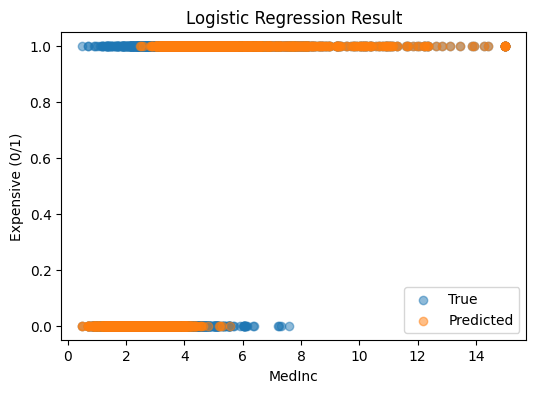

In [117]:
import matplotlib.pyplot as plt

x_first = X_test.iloc[:, 0]

plt.figure(figsize=(6,4))
plt.scatter(x_first, y_test, label="True", alpha=0.5)
plt.scatter(x_first, pred, label="Predicted", alpha=0.5)

plt.xlabel(X_test.columns[0])
plt.ylabel("Expensive (0/1)")
plt.legend()
plt.title("Logistic Regression Result")
plt.show()


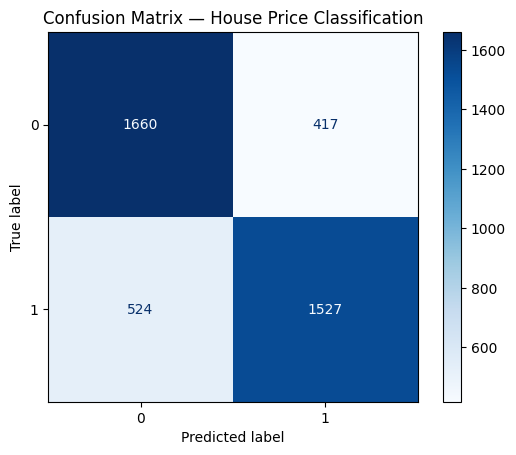

In [118]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix — House Price Classification")
plt.show()
